<a href="https://colab.research.google.com/github/vineetsalar88/ResearchPaper2/blob/master/April2026/5aprilConvNeXt_tiny.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models

from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

train_dir = "/content/drive/MyDrive/ResearchData/April26/5Classes/TrainvsTestDataset1140images/train"
val_dir =   "/content/drive/MyDrive/ResearchData/April26/5Classes/TrainvsTestDataset1140images/val"
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = len(os.listdir(train_dir))

In [3]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [4]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

class_names = train_dataset.classes

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.convnext_tiny(pretrained=True)

# Replace classifier
model.classifier[2] = nn.Linear(model.classifier[2].in_features, NUM_CLASSES)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Tiny_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 178MB/s] 


In [6]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(), lr=3e-4)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

In [9]:
import torch
from sklearn.metrics import accuracy_score

EPOCHS = 15

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(EPOCHS):

    # ================= TRAIN =================
    model.train()
    running_loss = 0

    train_preds = []
    train_labels = []

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Predictions for accuracy
        _, preds = torch.max(outputs, 1)

        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

    train_loss = running_loss / len(train_loader)
    train_acc = accuracy_score(train_labels, train_preds)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # ================= VALIDATION =================
    model.eval()
    running_loss = 0

    val_preds = []
    val_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_loss = running_loss / len(val_loader)
    val_acc = accuracy_score(val_labels, val_preds)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    # ================= PRINT =================
    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    # ================= SCHEDULER =================
    scheduler.step()


Epoch [1/15]
Train Loss: 0.3879 | Train Acc: 0.8397
Val   Loss: 0.7899 | Val   Acc: 0.7478

Epoch [2/15]
Train Loss: 0.2358 | Train Acc: 0.9058
Val   Loss: 0.7052 | Val   Acc: 0.7566

Epoch [3/15]
Train Loss: 0.1534 | Train Acc: 0.9395
Val   Loss: 0.9862 | Val   Acc: 0.7699

Epoch [4/15]
Train Loss: 0.2008 | Train Acc: 0.9271
Val   Loss: 0.8625 | Val   Acc: 0.7301

Epoch [5/15]
Train Loss: 0.1373 | Train Acc: 0.9484
Val   Loss: 0.7314 | Val   Acc: 0.7965

Epoch [6/15]
Train Loss: 0.0398 | Train Acc: 0.9910
Val   Loss: 0.8601 | Val   Acc: 0.7920

Epoch [7/15]
Train Loss: 0.0231 | Train Acc: 0.9933
Val   Loss: 0.7016 | Val   Acc: 0.7832

Epoch [8/15]
Train Loss: 0.0179 | Train Acc: 0.9966
Val   Loss: 0.8957 | Val   Acc: 0.7920

Epoch [9/15]
Train Loss: 0.0311 | Train Acc: 0.9922
Val   Loss: 0.8022 | Val   Acc: 0.7743

Epoch [10/15]
Train Loss: 0.0538 | Train Acc: 0.9832
Val   Loss: 1.0800 | Val   Acc: 0.7743

Epoch [11/15]
Train Loss: 0.0174 | Train Acc: 0.9944
Val   Loss: 0.6740 | Val 

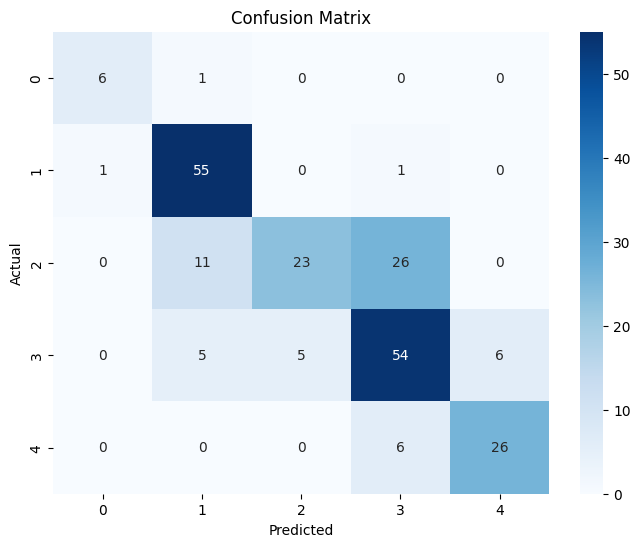

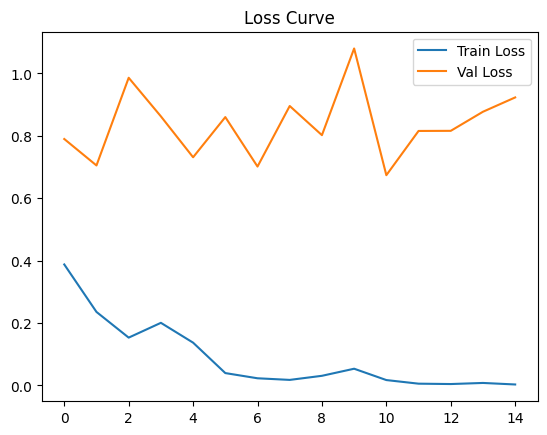

In [10]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
torch.save(model.state_dict(), "convnext_model.pth")
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()